In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/yolov9-main

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/sispanseg/train/images")
count_images("datasets/sispanseg/valid/images")

Total images: 200
Total images: 56


In [ ]:
import os
import shutil

# Set base dataset path here
base_path = "/content/gdrive/MyDrive/yolov9-main/datasets/sispanseg"

# Old folder names
old_train_images = os.path.join(base_path, "train", "images")
old_val_images = os.path.join(base_path, "valid", "images")

old_train_pngs = os.path.join(base_path, "train", "panoptic_rgb")
old_val_pngs = os.path.join(base_path, "valid", "panoptic_rgb")

old_train_annotations = os.path.join(base_path, "train", "panoptic_train.json")
old_val_annotations = os.path.join(base_path, "valid", "panoptic_val.json")

# New folder names
new_train_images = os.path.join(base_path, "train2017")
new_val_images = os.path.join(base_path, "val2017")

new_train_pngs = os.path.join(base_path, "annotations", "panoptic_train2017")
new_val_pngs = os.path.join(base_path, "annotations", "panoptic_val2017")

new_train_annotations = os.path.join(base_path, "annotations", "panoptic_train2017.json")
new_val_annotations = os.path.join(base_path, "annotations", "panoptic_val2017.json")

# 1. copy images folders to train2017 and val2017 (flat, not nested)
shutil.copytree(old_train_images, new_train_images)
shutil.copytree(old_val_images, new_val_images)

# 2. copy pngs folders to annotations' folders
shutil.copytree(old_train_pngs, new_train_pngs)
shutil.copytree(old_val_pngs, new_val_pngs)

# 3. copy json files to inside annotations
shutil.copy(old_train_annotations, new_train_annotations)
shutil.copy(old_val_annotations, new_val_annotations)

'/content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_val2017.json'

In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/sispanseg/train2017")
count_images("datasets/sispanseg/val2017")

Total images: 200
Total images: 56


In [ ]:
# Check train annotations
with open("datasets/sispanseg/annotations/panoptic_train2017.json") as f:
    train_data = json.load(f)
    print(f"Train images: {len(train_data['images'])}")
    print(f"Train annotations: {len(train_data['annotations'])}")
    print(f"Categories: {train_data['categories']}")

# Check validation
with open("datasets/sispanseg/annotations/panoptic_val2017.json") as f:
    valid_data = json.load(f)
    print(f"\nValid images: {len(valid_data['images'])}")
    print(f"Valid annotations: {len(valid_data['annotations'])}")

Train images: 200
Train annotations: 200
Categories: [{'id': 1, 'name': 'Grasper', 'isthing': 1}, {'id': 2, 'name': 'Harmonic ACE', 'isthing': 1}, {'id': 3, 'name': 'Myoma Screw', 'isthing': 1}, {'id': 4, 'name': 'Needle Holder', 'isthing': 1}, {'id': 5, 'name': 'Trocer', 'isthing': 1}, {'id': 6, 'name': 'Uterus', 'isthing': 0}, {'id': 7, 'name': 'Background', 'isthing': 0}]

Valid images: 56
Valid annotations: 56


In [ ]:
import os
import json

def count_images(image_dir, exts={".jpg", ".jpeg", ".png", ".bmp", ".webp"}):
    image_count = 0
    for filename in os.listdir(image_dir):
        if os.path.splitext(filename.lower())[1] in exts:
            image_count += 1
    print(f"Total images: {image_count}")

count_images("datasets/sispanseg/annotations/panoptic_train2017")
count_images("datasets/sispanseg/annotations/panoptic_val2017")

Total images: 200
Total images: 56


In [ ]:
import json
import os

def create_train_id_json(input_json_path, output_json_path):
    print(f"Loading {input_json_path}...")
    with open(input_json_path, 'r') as f:
        data = json.load(f)

    # Sort categories to ensure a deterministic mapping
    categories = sorted(data['categories'], key=lambda x: x['id'])

    # Create a mapping from original COCO category ID to sequential trainId (0, 1, 2...)
    id_to_train_id = {cat['id']: idx for idx, cat in enumerate(categories)}

    # Update category entries with the new trainId field
    for idx, cat in enumerate(data['categories']):
        cat['trainId'] = id_to_train_id[cat['id']]

    # Update category IDs in the annotations/segments_info list
    print("Updating annotation segment mappings...")
    for ann in data['annotations']:
        if 'segments_info' in ann:
            for segment in ann['segments_info']:
                orig_id = segment['category_id']
                if orig_id in id_to_train_id:
                    # Map the category_id to its new continuous train ID
                    segment['category_id'] = id_to_train_id[orig_id]
                else:
                    print(f"Warning: category_id {orig_id} found in segments but missing from categories list.")

    # Save the updated JSON data
    print(f"Saving new file to {output_json_path}...")
    os.makedirs(os.path.dirname(output_json_path), exist_ok=True)
    with open(output_json_path, 'w') as f:
        json.dump(data, f, indent=2)
    print("Successfully generated trainId annotation file!")

BASE_DIR = "/content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations"
train_input = os.path.join(BASE_DIR, "panoptic_train2017.json")
train_output = os.path.join(BASE_DIR, "panoptic_train2017_trainId.json")

# Execute conversion
create_train_id_json(train_input, train_output)

Loading /content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_train2017.json...
Updating annotation segment mappings...
Saving new file to /content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_train2017_trainId.json...
Successfully generated trainId annotation file!


In [ ]:
with open("/content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_train2017_trainId.json") as f:
    test_data = json.load(f)
    print("Sample updated categories:", test_data['categories'][:2])
    print("Sample updated segment info:", test_data['annotations'][0]['segments_info'][:2])

Sample updated categories: [{'id': 1, 'name': 'Grasper', 'isthing': 1, 'trainId': 0}, {'id': 2, 'name': 'Harmonic ACE', 'isthing': 1, 'trainId': 1}]
Sample updated segment info: [{'id': 1001, 'category_id': 0, 'area': 5401, 'bbox': [229, 933, 159, 65], 'iscrowd': 0}, {'id': 6000, 'category_id': 5, 'area': 650120, 'bbox': [498, 2, 931, 889], 'iscrowd': 0}]


In [ ]:
import json
import os

def create_val_train_id_json(train_json_path, val_json_path, output_val_path):
    # 1. Load training data to capture the correct ID mapping order
    print(f"Loading train data from {train_json_path}...")
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)

    # Recreate the exact mapping used during training (sorted by original ID)
    train_categories = sorted(train_data['categories'], key=lambda x: x['id'])
    id_to_train_id = {cat['id']: idx for idx, cat in enumerate(train_categories)}

    # 2. Load validation data
    print(f"Loading validation data from {val_json_path}...")
    with open(val_json_path, 'r') as f:
        val_data = json.load(f)

    # 3. Apply the training mapping to validation categories
    for cat in val_data['categories']:
        orig_id = cat['id']
        if orig_id in id_to_train_id:
            cat['trainId'] = id_to_train_id[orig_id]
        else:
            print(f"Warning: Category {cat['name']} (ID {orig_id}) in validation but missing from train.")

    # 4. Map the category IDs in validation segments
    print("Updating validation annotation segment mappings...")
    for ann in val_data['annotations']:
        if 'segments_info' in ann:
            for segment in ann['segments_info']:
                orig_id = segment['category_id']
                if orig_id in id_to_train_id:
                    segment['category_id'] = id_to_train_id[orig_id]
                else:
                    print(f"Warning: Segment category_id {orig_id} missing from train mapping.")

    # 5. Save the updated validation JSON
    print(f"Saving validation file to {output_val_path}...")
    os.makedirs(os.path.dirname(output_val_path), exist_ok=True)
    with open(output_val_path, 'w') as f:
        json.dump(val_data, f, indent=2)
    print("Successfully generated validation trainId annotation file!")

BASE_DIR = "/content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations"
train_input = os.path.join(BASE_DIR, "panoptic_train2017.json")
val_input = os.path.join(BASE_DIR, "panoptic_val2017.json")
val_output = os.path.join(BASE_DIR, "panoptic_val2017_trainId.json")

# Execute conversion
create_val_train_id_json(train_input, val_input, val_output)

Loading train data from /content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_train2017.json...
Loading validation data from /content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_val2017.json...
Updating validation annotation segment mappings...
Saving validation file to /content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_val2017_trainId.json...
Successfully generated validation trainId annotation file!


In [ ]:
with open("/content/gdrive/MyDrive/yolov9-main/datasets/sispanseg/annotations/panoptic_val2017_trainId.json") as f:
    test_data = json.load(f)
    print("Sample updated categories:", test_data['categories'][:2])
    print("Sample updated segment info:", test_data['annotations'][0]['segments_info'][:2])

Sample updated categories: [{'id': 1, 'name': 'Grasper', 'isthing': 1, 'trainId': 0}, {'id': 2, 'name': 'Harmonic ACE', 'isthing': 1, 'trainId': 1}]
Sample updated segment info: [{'id': 4001, 'category_id': 3, 'area': 53017, 'bbox': [204, 426, 621, 567], 'iscrowd': 0}, {'id': 4002, 'category_id': 3, 'area': 72543, 'bbox': [140, 424, 930, 385], 'iscrowd': 0}]


In [ ]:
!pip install git+https://github.com/cocodataset/panopticapi.git

In [ ]:
!git clone https://github.com/bowenc0221/panoptic-deeplab.git
!cd panoptic-deeplab
!pip install -r requirements.txt
!cd ..

In [ ]:
!pip install fvcore

In [ ]:
import os

def replace_np_float(repo_path):
    for root, _, files in os.walk(repo_path):
        for file in files:
            if file.endswith('.py'):
                filepath = os.path.join(root, file)
                with open(filepath, 'r', encoding='utf-8') as f:
                    content = f.read()

                new_content = content.replace('float6464', 'float64')
                # Optional: uncomment below to replace np.int as well
                # new_content = new_content.replace('np.int', 'int')

                if new_content != content:
                    with open(filepath, 'w', encoding='utf-8') as f:
                        f.write(new_content)
                    print(f'Fixed np.float in {filepath}')

if __name__ == '__main__':
    repo_root = '/content/gdrive/MyDrive/yolov9-main/panoptic-deeplab'  # change if needed
    replace_np_float(repo_root)
    print("All done!")

All done!


In [5]:
import sys
import os
import yaml
import numpy as np
import torch

sys.path.insert(0, '/content/gdrive/MyDrive/yolov9-main/panoptic-deeplab')

In [6]:
!mkdir -p /root/.cache/torch/hub/checkpoints/
!cp /content/gdrive/MyDrive/yolov9-main/output/hrnetv2_w48_imagenet_pretrained.pth \
   /root/.cache/torch/hub/checkpoints/hrnetv2_w48_imagenet_pretrained.pth

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import cv2

def show_predictions_grid(semantic_dir, instance_dir, panoptic_dir, max_images=5):
    # --- collect image paths ---
    semantic_imgs = sorted(glob.glob(os.path.join(semantic_dir, "semantic_pred_*.png")))
    instance_imgs = sorted(glob.glob(os.path.join(instance_dir, "panoptic_to_instance_pred_*.png")))
    panoptic_imgs = sorted(glob.glob(os.path.join(panoptic_dir, "panoptic_pred_*.png")))

    # take minimum available count
    n = min(len(semantic_imgs), len(instance_imgs), len(panoptic_imgs), max_images)

    # --- prepare grid ---
    fig, axs = plt.subplots(n, 3, figsize=(15, 15))

    if n == 1:
        axs = [axs]  # make iterable if single row

    for i in range(n):
        sem = cv2.imread(semantic_imgs[i])[:, :, ::-1]   # BGR->RGB
        ins = cv2.imread(instance_imgs[i])[:, :, ::-1]
        pan = cv2.imread(panoptic_imgs[i])[:, :, ::-1]

        axs[i][0].imshow(sem)
        axs[i][1].imshow(ins)
        axs[i][2].imshow(pan)

        for ax in axs[i]:
            ax.axis("off")

    # set titles only on top row
    axs[0][0].set_title("Semantic", fontsize=14)
    axs[0][1].set_title("Instance", fontsize=14)
    axs[0][2].set_title("Panoptic", fontsize=14)

    plt.tight_layout()
    plt.show()

In [ ]:
!python panoptic-deeplab/tools/demo.py \
  --cfg panoptic-deeplab/configs/panoptic_deeplab_H48_os4_cityscapes.yaml \
  --input-files /content/gdrive/MyDrive/PaddleDet-Models/datasets/panoptic-tests/street1.png \
  --output-dir /content/gdrive/MyDrive/yolov9-main/output/street1results/ \
  TEST.MODEL_FILE /content/gdrive/MyDrive/yolov9-main/output/panoptic_deeplab_H48_os4_cityscapes.pth

[05/14 16:05:41 demo]: Namespace(cfg='panoptic-deeplab/configs/panoptic_deeplab_H48_os4_cityscapes.yaml', input_files='/content/gdrive/MyDrive/PaddleDet-Models/datasets/panoptic-tests/street1.png', output_dir='/content/gdrive/MyDrive/yolov9-main/output/street1results/', extension='.png', merge_image=False, opts=['TEST.MODEL_FILE', '/content/gdrive/MyDrive/yolov9-main/output/panoptic_deeplab_H48_os4_cityscapes.pth'])
[05/14 16:05:41 demo]: CKPT_FREQ: 5000
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATALOADER:
  NUM_WORKERS: 4
  SAMPLER_TRAIN: TrainingSampler
  TRAIN_SHUFFLE: True
DATASET:
  CROP_SIZE: (1025, 2049)
  DATASET: cityscapes_panoptic
  IGNORE_STUFF_IN_OFFSET: True
  MAX_RESIZE_VALUE: -1
  MAX_SCALE: 2.0
  MEAN: (0.485, 0.456, 0.406)
  MIN_RESIZE_VALUE: -1
  MIN_SCALE: 0.5
  MIRROR: True
  NUM_CLASSES: 19
  RESIZE_FACTOR: -1
  ROOT: ./datasets/cityscapes
  SCALE_STEP_SIZE: 0.1
  SEMANTIC_ONLY: False
  SMALL_INSTANCE_AREA: 4096
  SMALL_INSTANCE_WEIGHT: 3
  

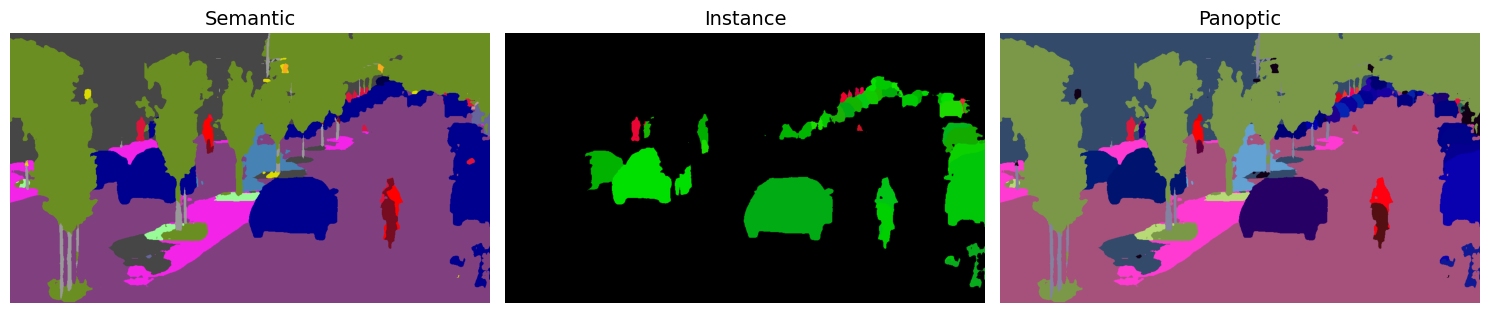

In [ ]:
show_predictions_grid(
    "/content/gdrive/MyDrive/yolov9-main/output/street1results/semantic",
    "/content/gdrive/MyDrive/yolov9-main/output/street1results/instance",
    "/content/gdrive/MyDrive/yolov9-main/output/street1results/panoptic",
    max_images=1)

In [7]:
!ls /content/gdrive/MyDrive/yolov9-main/panoptic-deeplab/configs/

Misc
panoptic_deeplab_H48_os4_cityscapes.yaml
panoptic_deeplab_MBNV2_100_os32_cityscapes_bs16_lr_x2.yaml
panoptic_deeplab_R101_os32_cityscapes.yaml
panoptic_deeplab_R50_os32_cityscapes.yaml
panoptic_deeplab_X101_32x8d_os32_cityscapes.yaml
panoptic_deeplab_X65_os32_cityscapes_lr_x10.yaml
sis_R50.yaml


In [8]:
one_epoch = 200/2
print(one_epoch)
total_iters = one_epoch * 20
print(total_iters)

100.0
2000.0


In [ ]:
custom_cfg = """
MODEL:
  META_ARCHITECTURE: "panoptic_deeplab"
  BN_MOMENTUM: 0.01
  BACKBONE:
    NAME: "resnet50"
    DILATION: (False, False, False)
    PRETRAINED: True
  DECODER:
    IN_CHANNELS: 2048
    FEATURE_KEY: "res5"
    DECODER_CHANNELS: 256
    ATROUS_RATES: (3, 6, 9)
  PANOPTIC_DEEPLAB:
    LOW_LEVEL_CHANNELS: (1024, 512, 256)
    LOW_LEVEL_KEY: ["res4", "res3", "res2"]
    LOW_LEVEL_CHANNELS_PROJECT: (128, 64, 32)
    INSTANCE:
      ENABLE: True
      LOW_LEVEL_CHANNELS_PROJECT: (64, 32, 16)
      DECODER_CHANNELS: 128
      HEAD_CHANNELS: 32
      ASPP_CHANNELS: 256
      NUM_CLASSES: (1, 2)   # Center (1) and Offset (2) outputs for instance branch
      CLASS_KEY: ["center", "offset"]

DATASET:
  ROOT: "/content/gdrive/MyDrive/yolov9-main/datasets/sispanseg"
  DATASET: 'coco_panoptic'
  NUM_CLASSES: 7
  TRAIN_SPLIT: "train2017"
  TEST_SPLIT: "val2017"
  CROP_SIZE: (1025, 2049)
  MIRROR: True
  MIN_SCALE: 1.1
  MAX_SCALE: 1.2
  SCALE_STEP_SIZE: 0.1
  MEAN: (0.485, 0.456, 0.406)
  STD: (0.229, 0.224, 0.225)
  SEMANTIC_ONLY: False
  IGNORE_STUFF_IN_OFFSET: True
  SMALL_INSTANCE_AREA: 100
  SMALL_INSTANCE_WEIGHT: 3

SOLVER:
  BASE_LR: 0.00005
  WEIGHT_DECAY: 0.0
  WEIGHT_DECAY_NORM: 0.0
  BIAS_LR_FACTOR: 1.0
  WEIGHT_DECAY_BIAS: 0.0
  OPTIMIZER: "adam"
  LR_SCHEDULER_NAME: "WarmupPolyLR"
  WARMUP_ITERS: 100

LOSS:
  SEMANTIC:
    NAME: "hard_pixel_mining"
    IGNORE: 255
    TOP_K_PERCENT: 0.2
    WEIGHT: 10.0
  CENTER:
    NAME: "mse"
    WEIGHT: 100.0
  OFFSET:
    NAME: "l1"
    WEIGHT: 1.0

TRAIN:
  IMS_PER_BATCH: 2
  MAX_ITER: 2000

DEBUG:
  DEBUG: True
  DEBUG_FREQ: 100

TEST:
  EVAL_INSTANCE: True
  EVAL_PANOPTIC: True

POST_PROCESSING:
  CENTER_THRESHOLD: 0.1
  NMS_KERNEL: 7
  TOP_K_INSTANCE: 200
  STUFF_AREA: 2048

OUTPUT_DIR: "./output/sis_weights"
GPUS: (0,)   # Single GPU on Colab
WORKERS: 2
"""

with open('panoptic-deeplab/configs/sis_R50.yaml', 'w') as f:
    f.write(custom_cfg)

In [ ]:
import json
import re

# 1. Read true lengths
with open("datasets/sispanseg/annotations/panoptic_train2017.json") as f:
    train_count = len(json.load(f)['images'])
with open("datasets/sispanseg/annotations/panoptic_val2017.json") as f:
    val_count = len(json.load(f)['images'])

target_file = "/content/gdrive/MyDrive/yolov9-main/panoptic-deeplab/segmentation/data/datasets/coco_panoptic.py"

# 2. Modify the target script
with open(target_file, "r") as f:
    content = f.read()

# Update hardcoded constants dynamically
content = re.sub(r"'train2017':\s*\d+", f"'train2017': {train_count}", content)
content = re.sub(r"'val2017':\s*\d+", f"'val2017': {val_count}", content)

with open(target_file, "w") as f:
    f.write(content)

print(f"Patched dataset sizes successfully: train={train_count}, val={val_count}")

Patched dataset sizes successfully: train=200, val=56


In [ ]:
import sys
import os
import yaml
import numpy as np
import torch

sys.path.insert(0, '/content/gdrive/MyDrive/yolov9-main/panoptic-deeplab')

from segmentation.data.datasets.coco_panoptic import COCOPanoptic

# Load config
with open('/content/gdrive/MyDrive/yolov9-main/panoptic-deeplab/configs/sis_R50.yaml') as f:
    cfg = yaml.safe_load(f)

root_path = cfg['DATASET']['ROOT']
train_split = cfg['DATASET']['TRAIN_SPLIT']

dataset = COCOPanoptic(root=root_path, split=train_split)

print(f"Dataset length: {len(dataset)}")

sample = dataset[10]

image = sample['image']
target = {
    'semantic': sample['semantic'],
    'foreground': sample['foreground'],
    'center': sample['center'],
    'center_points': sample.get('center_points', []),
    'offset': sample['offset'],
    'semantic_weights': sample['semantic_weights'],
    'center_weights': sample['center_weights'],
    'offset_weights': sample['offset_weights'],
}

print(f"Image shape: {image.shape}")
print(f"Target keys: {target.keys()}")

if 'semantic' in target:
    print(f"Unique semantic mask values in first sample: {target['semantic'].unique()}")

# ✅ Check all labels across full dataset
all_labels = set()

for idx in range(len(dataset)):
    sample = dataset[idx]
    semantic = sample['semantic']
    unique_vals = torch.unique(semantic).cpu().numpy()
    all_labels.update(unique_vals.tolist())

print(f"\n✅ Unique semantic labels across all dataset: {sorted(all_labels)}")

expected_labels = [0, 1, 2, 3, 4, 5, 6, 255]

missing = [label for label in expected_labels if label not in all_labels]
if len(missing) == 0:
    print("\n✅ All expected labels are present!")
else:
    print(f"\n⚠️ Missing labels: {missing}")

Dataset length: 200
Image shape: torch.Size([3, 1024, 1024])
Target keys: dict_keys(['semantic', 'foreground', 'center', 'center_points', 'offset', 'semantic_weights', 'center_weights', 'offset_weights'])
Unique semantic mask values in first sample: tensor([  1,   2,   5,   6, 255])

✅ Unique semantic labels across all dataset: [0, 1, 2, 3, 4, 5, 6, 255]

✅ All expected labels are present!


In [ ]:
!python panoptic-deeplab/tools/train_net.py --cfg panoptic-deeplab/configs/sis_R50.yaml

[05/15 12:49:52 segmentation]: Namespace(cfg='panoptic-deeplab/configs/sis_R50.yaml', local_rank=0, opts=[])
[05/15 12:49:52 segmentation]: CKPT_FREQ: 5000
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATALOADER:
  NUM_WORKERS: 4
  SAMPLER_TRAIN: TrainingSampler
  TRAIN_SHUFFLE: True
DATASET:
  CROP_SIZE: (1025, 2049)
  DATASET: coco_panoptic
  IGNORE_STUFF_IN_OFFSET: True
  MAX_RESIZE_VALUE: -1
  MAX_SCALE: 1.2
  MEAN: (0.485, 0.456, 0.406)
  MIN_RESIZE_VALUE: -1
  MIN_SCALE: 1.1
  MIRROR: True
  NUM_CLASSES: 7
  RESIZE_FACTOR: -1
  ROOT: /content/gdrive/MyDrive/yolov9-main/datasets/sispanseg
  SCALE_STEP_SIZE: 0.1
  SEMANTIC_ONLY: False
  SMALL_INSTANCE_AREA: 100
  SMALL_INSTANCE_WEIGHT: 3
  STD: (0.229, 0.224, 0.225)
  TEST_SPLIT: val2017
  TRAIN_SPLIT: train2017
DEBUG:
  DEBUG: True
  DEBUG_FREQ: 100
  KEEP_INTERVAL: 1000
  OUTPUT_KEYS: ('semantic', 'center', 'offset')
  TARGET_KEYS: ('semantic', 'center', 'offset', 'semantic_weights', 'center_weights', 'offset_w

In [9]:
!ls /content/gdrive/MyDrive/yolov9-main/output/sis_weights/

checkpoint.pth.tar  debug_train  final_state.pth  log.txt


In [ ]:
/content/gdrive/MyDrive/yolov9-main/panoptic-deeplab/segmentation/data/datasets/coco_panoptic.py

In [ ]:
/content/gdrive/MyDrive/yolov9-main/panoptic-deeplab/tools/demo.py

In [ ]:
# !python panoptic-deeplab/tools/demo.py \
#   --cfg panoptic-deeplab/configs/sis_R50.yaml \
#   --input-files /content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/ \
#   --output-dir /content/gdrive/MyDrive/yolov9-main/output/sis_results \
#   TEST.MODEL_FILE /content/gdrive/MyDrive/yolov9-main/output/sis_weights/final_state.pth \
#   POST_PROCESSING.CENTER_THRESHOLD 0.1 \
#   POST_PROCESSING.NMS_KERNEL 7 \
#   POST_PROCESSING.TOP_K_INSTANCE 200

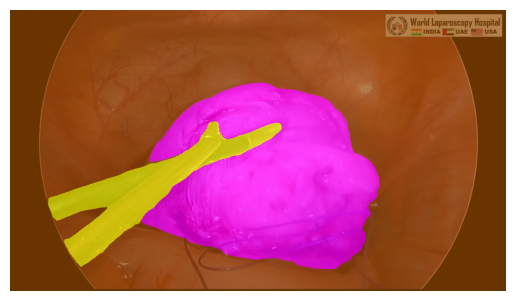

In [80]:
import os
import random
import glob
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image

CONFIG_PATH = "panoptic-deeplab/configs/sis_R50.yaml"
WEIGHTS_PATH = "/content/gdrive/MyDrive/yolov9-main/output/sis_weights/final_state.pth"
INPUT_DIR = "/content/gdrive/MyDrive/Pytorch-Models/datasets/sispanseg/valid/images/"
LABEL_DIVISOR = 256

THING_LIST = [0, 1, 2, 3, 4]

COCO_CATEGORIES = [
    {"color": (255, 0, 0), "isthing": 1, "id": 1, "trainId": 0, "name": "Grasper"},
    {"color": (0, 255, 0), "isthing": 1, "id": 2, "trainId": 1, "name": "Harmonic-ACE"},
    {"color": (0, 0, 255), "isthing": 1, "id": 3, "trainId": 2, "name": "Myoma-Screw"},
    {"color": (255, 255, 0), "isthing": 1, "id": 4, "trainId": 3, "name": "Needle-Holder"},
    {"color": (0, 255, 255), "isthing": 1, "id": 5, "trainId": 4, "name": "Trocer"},
    {"color": (255, 0, 255), "isthing": 0, "id": 6, "trainId": 5, "name": "Uterus"},
    {"color": (150, 75, 0), "isthing": 0, "id": 7, "trainId": 6, "name": "BG"},
]

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

from segmentation.config import config as cfg
from segmentation.config import update_config
from segmentation.model import build_segmentation_model_from_cfg
from segmentation.model.post_processing import get_semantic_segmentation, get_panoptic_segmentation

class DummyArgs:
    cfg = CONFIG_PATH
    opts = []
update_config(cfg, DummyArgs)

cfg.defrost()
cfg.TEST.MODEL_FILE = WEIGHTS_PATH
cfg.DATASET.NUM_CLASSES = 7
cfg.freeze()

model = build_segmentation_model_from_cfg(cfg)

model_weights = torch.load(WEIGHTS_PATH, map_location=device)
if 'state_dict' in model_weights.keys():
    model_weights = model_weights['state_dict']
model.load_state_dict(model_weights, strict=True)
model = model.to(device).eval()

image_paths = sorted(glob.glob(os.path.join(INPUT_DIR, "*.[jJ][pP][gG]")) +
                     glob.glob(os.path.join(INPUT_DIR, "*.[pP][nN][gG]")))

if not image_paths:
    raise FileNotFoundError(f"No valid images found inside: {INPUT_DIR}")

random_img_path = random.choice(image_paths)

with torch.no_grad():
    # A. Load raw image matrix
    raw_image = np.array(Image.open(random_img_path).convert('RGB'))
    orig_h, orig_w = raw_image.shape[:2]

    # B. Scale image smoothly to model training resolutions
    target_h, target_w = (2049, 1025) # cfg.DATASET.CROP_SIZE
    resized_image = cv2.resize(raw_image, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    raw_h, raw_w = resized_image.shape[:2]

    # C. Divisible network dimension padding
    new_h = (raw_h + 31) // 32 * 32 + 1
    new_w = (raw_w + 31) // 32 * 32 + 1
    input_image = np.zeros((new_h, new_w, 3), dtype=np.uint8)
    input_image[:, :] = [int(m * 255) if m <= 1.0 else int(m) for m in cfg.DATASET.MEAN]
    input_image[:raw_h, :raw_w, :] = resized_image

    # D. Format input tensor and apply ImageNet normalization multipliers
    image_tensor = torch.from_numpy(input_image.copy()).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = (image_tensor - mean) / std
    image_tensor = image_tensor.unsqueeze(0).to(device)

    # E. Forward propagation pass
    out_dict = model(image_tensor)

    # F. Run post-processing clusters (Using the corrected THING_LIST)
    semantic_pred = get_semantic_segmentation(out_dict['semantic'])
    panoptic_pred, _ = get_panoptic_segmentation(
        semantic_pred,
        out_dict['center'],
        out_dict['offset'],
        thing_list=THING_LIST,
        label_divisor=LABEL_DIVISOR,
        stuff_area=cfg.POST_PROCESSING.STUFF_AREA,
        void_label=LABEL_DIVISOR * 255,
        threshold=0.1,
        nms_kernel=7,
        top_k=200,
        foreground_mask=None
    )

    # G. Array retrieval and resolution reconstruction back to original native dimensions
    panoptic_arr = panoptic_pred.squeeze(0).cpu().numpy()[:raw_h, :raw_w]
    panoptic_final = cv2.resize(panoptic_arr, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

    # H. Build instance colors mask mapping using defined colors
    color_mask = np.zeros_like(raw_image)
    unique_instances = np.unique(panoptic_final)

    # Create class-to-color lookup map directly from COCO_CATEGORIES list
    class_colors = {cat['trainId']: cat['color'] for cat in COCO_CATEGORIES}

    for inst in unique_instances:
        # Stop void pixels or empty assignments from breaking calculations
        if inst == (LABEL_DIVISOR * 255) or inst == 0:
            continue

        mask = (panoptic_final == inst)
        cat_id = int(inst // LABEL_DIVISOR)

        # Do not overlay color onto the BG class (trainId 6). Keep it completely clear.
        # if cat_id == 6:
        #     continue

        if cat_id in class_colors:
            color_mask[mask] = np.array(class_colors[cat_id], dtype=np.uint8)

    fused_visualization = cv2.addWeighted(raw_image, 0.3, color_mask, 0.7, 0)

    plt.imshow(fused_visualization)
    plt.axis('off')
    plt.show()

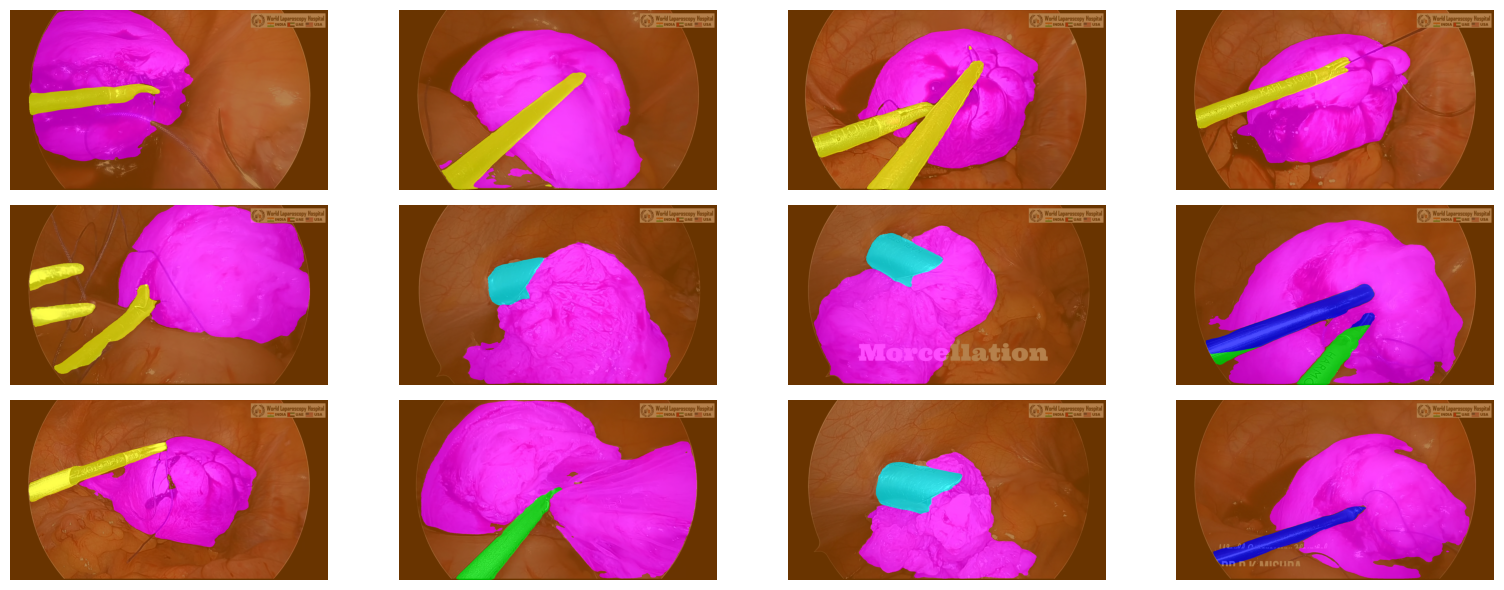

In [81]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import cv2
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/datasets/sispanseg/valid/images/"

# Class ID -> RGB Color
custom_color_map = {
    0: (255, 0, 0),      # Grasper (Red)
    1: (0, 255, 0),      # Harmonic-ACE (Green)
    2: (0, 0, 255),      # Myoma-Screw (Blue)
    3: (255, 255, 0),    # Needle-Holder (Yellow)
    4: (0, 255, 255),    # Trocar (Cyan)
    5: (255, 0, 255),    # Uterus (Magenta)
    6: (150, 75, 0),     # BG (Brown)
}

# Map class IDs to tool names
id2label = {
    0: "Grasper",
    1: "Harmonic-ACE",
    2: "Myoma-Screw",
    3: "Needle-Holder",
    4: "Trocar",
    5: "Uterus",
    6: "BG",
    7: "Background/Void"
}

# visualization layout
N = 12
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(3, 4, ii+1)

    raw_image = np.array(Image.open(image).convert('RGB'))
    orig_h, orig_w = raw_image.shape[:2]

    target_h, target_w = (2049, 1025) # cfg.DATASET.CROP_SIZE
    resized_image = cv2.resize(raw_image, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    raw_h, raw_w = resized_image.shape[:2]

    new_h = (raw_h + 31) // 32 * 32 + 1
    new_w = (raw_w + 31) // 32 * 32 + 1
    input_image = np.zeros((new_h, new_w, 3), dtype=np.uint8)
    input_image[:, :] = [int(m * 255) if m <= 1.0 else int(m) for m in cfg.DATASET.MEAN]
    input_image[:raw_h, :raw_w, :] = resized_image

    image_tensor = torch.from_numpy(input_image.copy()).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = (image_tensor - mean) / std
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        out_dict = model(image_tensor)

        semantic_pred = get_semantic_segmentation(out_dict['semantic'])
        panoptic_pred, _ = get_panoptic_segmentation(
            semantic_pred,
            out_dict['center'],
            out_dict['offset'],
            thing_list=THING_LIST,
            label_divisor=LABEL_DIVISOR,
            stuff_area=cfg.POST_PROCESSING.STUFF_AREA,
            void_label=LABEL_DIVISOR * 255,
            threshold=0.1,
            nms_kernel=7,
            top_k=200,
            foreground_mask=None
        )

        panoptic_arr = panoptic_pred.squeeze(0).cpu().numpy()[:raw_h, :raw_w]
        panoptic_final = cv2.resize(panoptic_arr, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

        color_mask = np.zeros_like(raw_image)
        unique_instances = np.unique(panoptic_final)
        class_colors = {cat['trainId']: cat['color'] for cat in COCO_CATEGORIES}

        for inst in unique_instances:
            if inst == (LABEL_DIVISOR * 255) or inst == 0:
                continue

            mask = (panoptic_final == inst)
            cat_id = int(inst // LABEL_DIVISOR)

            # Do not overlay color onto the BG class (trainId 6). Keep it completely clear.
            # if cat_id == 6:
            #     continue

            if cat_id in class_colors:
                color_mask[mask] = np.array(class_colors[cat_id], dtype=np.uint8)

        overlay = cv2.addWeighted(raw_image, 0.3, color_mask, 0.7, 0)

        plt.subplot(rows, cols, ii + 1)
        plt.imshow(overlay)
        plt.axis("off")

plt.tight_layout()
plt.show()

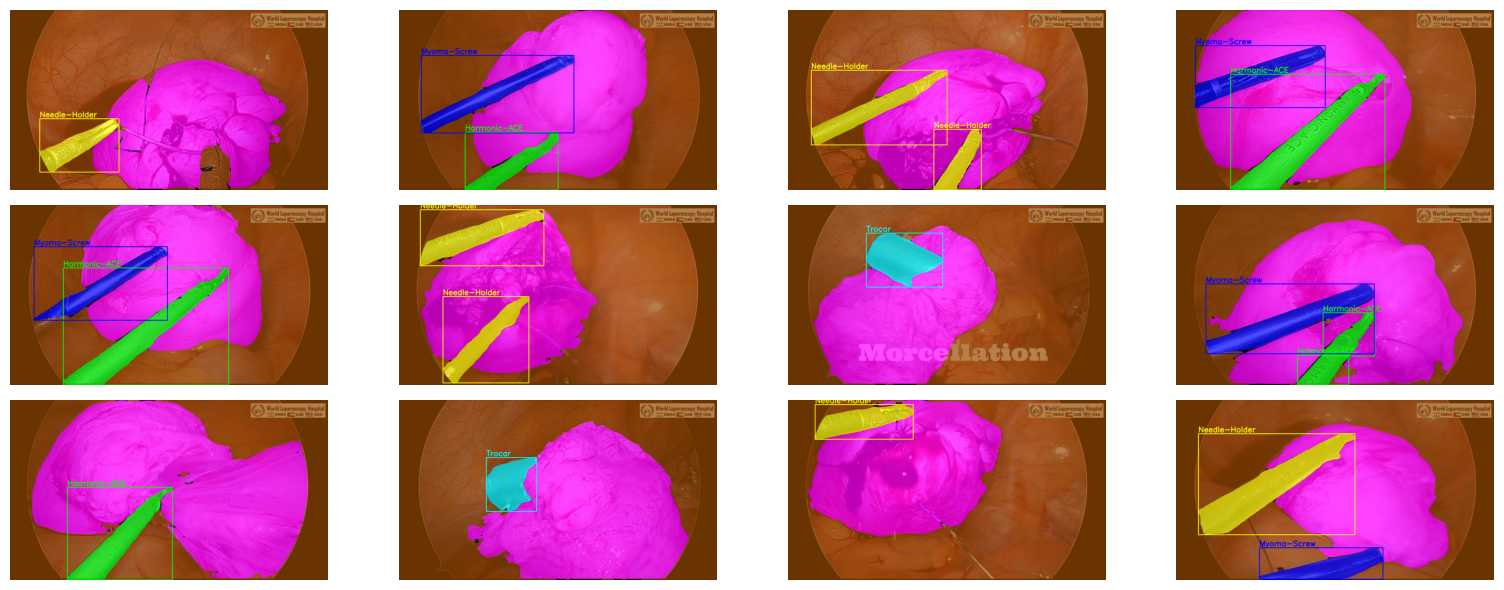

In [123]:
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import cv2
# ---------------- CONFIG ----------------
val_dir = "/content/gdrive/MyDrive/PaddleDet-Models/datasets/sispanseg/valid/images/"

# Class ID -> RGB Color
custom_color_map = {
    0: (255, 0, 0),      # Grasper (Red)
    1: (0, 255, 0),      # Harmonic-ACE (Green)
    2: (0, 0, 255),      # Myoma-Screw (Blue)
    3: (255, 255, 0),    # Needle-Holder (Yellow)
    4: (0, 255, 255),    # Trocar (Cyan)
    5: (255, 0, 255),    # Uterus (Magenta)
    6: (150, 75, 0),     # BG (Brown)
}

# Map class IDs to tool names
id2label = {
    0: "Grasper",
    1: "Harmonic-ACE",
    2: "Myoma-Screw",
    3: "Needle-Holder",
    4: "Trocar",
    5: "Uterus",
    6: "BG",
    7: "Background/Void"
}

# visualization layout
N = 12
cols = 4
rows = int(np.ceil(N / cols))

# random image selection
all_imgs = [os.path.join(val_dir, f)
            for f in os.listdir(val_dir)
            if f.lower().endswith((".jpg", ".png", ".jpeg"))]

sample_imgs = random.sample(all_imgs, N)

plt.figure(figsize=(4 * cols, 2 * rows))

for ii, image in enumerate(sample_imgs):
    plt.subplot(3, 4, ii+1)

    raw_image = np.array(Image.open(image).convert('RGB'))
    orig_h, orig_w = raw_image.shape[:2]

    target_h, target_w = (2049, 1025) # cfg.DATASET.CROP_SIZE
    resized_image = cv2.resize(raw_image, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    raw_h, raw_w = resized_image.shape[:2]

    new_h = (raw_h + 31) // 32 * 32 + 1
    new_w = (raw_w + 31) // 32 * 32 + 1
    input_image = np.zeros((new_h, new_w, 3), dtype=np.uint8)
    input_image[:, :] = [int(m * 255) if m <= 1.0 else int(m) for m in cfg.DATASET.MEAN]
    input_image[:raw_h, :raw_w, :] = resized_image

    image_tensor = torch.from_numpy(input_image.copy()).permute(2, 0, 1).float() / 255.0
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image_tensor = (image_tensor - mean) / std
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        out_dict = model(image_tensor)

        semantic_pred = get_semantic_segmentation(out_dict['semantic'])
        panoptic_pred, _ = get_panoptic_segmentation(
            semantic_pred,
            out_dict['center'],
            out_dict['offset'],
            thing_list=THING_LIST,
            label_divisor=LABEL_DIVISOR,
            stuff_area=cfg.POST_PROCESSING.STUFF_AREA,
            void_label=LABEL_DIVISOR * 255,
            threshold=0.1,
            nms_kernel=7,
            top_k=200,
            foreground_mask=None
        )

        panoptic_arr = panoptic_pred.squeeze(0).cpu().numpy()[:raw_h, :raw_w]
        panoptic_final = cv2.resize(panoptic_arr, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)

        color_mask = np.zeros_like(raw_image)
        unique_instances = np.unique(panoptic_final)
        class_colors = {cat['trainId']: cat['color'] for cat in COCO_CATEGORIES}

        # things_instances = []

        # for inst in unique_instances:
        #     if inst == (LABEL_DIVISOR * 255) or inst == 0:
        #         continue

        #     mask = (panoptic_final == inst)
        #     cat_id = int(inst // LABEL_DIVISOR)

        #     # Do not overlay color onto the BG class (trainId 6). Keep it completely clear.
        #     # if cat_id == 6:
        #     #     continue

        #     if 0 <= cat_id <= 4:
        #         things_instances.append((int(cat_id), mask))

        #     if cat_id in class_colors:
        #         color_mask[mask] = np.array(class_colors[cat_id], dtype=np.uint8)

        # overlay = cv2.addWeighted(raw_image, 0.3, color_mask, 0.7, 0)

        things_instances = []

        THING_CLASSES = [0, 1, 2, 3, 4]
        MIN_THING_AREA = 25000

        for inst in unique_instances:
            if inst == (LABEL_DIVISOR * 255) or inst == 0:
                continue

            mask = (panoptic_final == inst)
            cat_id = int(inst // LABEL_DIVISOR)

            # 1. Clean the instance mask immediately
            binary = mask.astype(np.uint8)
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
            binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

            num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)

            final_mask = (binary > 0)
            recovered_pixels = {}

            for label_id in range(1, num_labels):
                area = stats[label_id, cv2.CC_STAT_AREA]

                # 2. Identify true small components within this instance
                if cat_id in THING_CLASSES and area < MIN_THING_AREA:
                    component = (labels == label_id).astype(np.uint8)
                    dilated = cv2.dilate(component, np.ones((25, 25), np.uint8), iterations=1)

                    # Sample directly from color_mask to see clean, already-painted neighbors
                    neighbor_colors = color_mask[dilated > 0]
                    neighbor_colors = neighbor_colors.reshape(-1, 3)

                    current_color = np.array(class_colors.get(cat_id, [0,0,0]))
                    valid_pixels = []

                    for pixel in neighbor_colors:
                        if not np.array_equal(pixel, [0, 0, 0]) and not np.array_equal(pixel, current_color):
                            for cid, col in class_colors.items():
                                if np.array_equal(pixel, col):
                                    valid_pixels.append(cid)
                                    break

                    if len(valid_pixels) > 0:
                        replacement_cat = int(np.bincount(valid_pixels).argmax())
                    else:
                        replacement_cat = 6

                    final_mask[labels == label_id] = False

                    if replacement_cat not in recovered_pixels:
                        recovered_pixels[replacement_cat] = np.zeros_like(mask)
                    recovered_pixels[replacement_cat][labels == label_id] = True

            # 3. Paint valid surviving components safely (This creates valid target boxes)
            if np.any(final_mask):
                if 0 <= cat_id <= 4:
                    things_instances.append((int(cat_id), final_mask))
                if cat_id in class_colors:
                    color_mask[final_mask] = np.array(class_colors[cat_id], dtype=np.uint8)

            # 4. CRITICAL FIX: Merge recovered pixels into existing masks to prevent new bboxes
            for target_cat, target_mask in recovered_pixels.items():
                # Color mask must always be painted for clean visual feedback
                if target_cat in class_colors:
                    color_mask[target_mask] = np.array(class_colors[target_cat], dtype=np.uint8)

                if 0 <= target_cat <= 4:
                    merged = False
                    # Look backwards through already registered objects to find a merge partner
                    for idx, (existing_cat, existing_mask) in enumerate(reversed(things_instances)):
                        if existing_cat == target_cat:
                            # Verify if the noise is touching/near this existing object mask
                            # Use dilation to see if the noise footprint overlaps with the parent object footprint
                            check_dilation = cv2.dilate(target_mask.astype(np.uint8), np.ones((5, 5), np.uint8))
                            if np.any(check_dilation & existing_mask):
                                # Re-calculate actual index from the reversed loop
                                true_idx = len(things_instances) - 1 - idx
                                # Merge the pixels directly into the existing bounding box track
                                things_instances[true_idx] = (existing_cat, existing_mask | target_mask)
                                merged = True
                                break

                    # If it's a completely isolated island, skip appending it to things_instances entirely!

        overlay = cv2.addWeighted(raw_image, 0.3, color_mask, 0.7, 0)

        for cls, mask in things_instances:
            ys, xs = np.where(mask)

            if len(xs) == 0:
                continue

            x1, y1 = xs.min(), ys.min()
            x2, y2 = xs.max(), ys.max()

            color = np.array(custom_color_map[cls])

            cv2.rectangle(overlay, (x1, y1), (x2, y2), color.tolist(), 3)

            label_name = id2label[cls]

            cv2.putText(
                overlay,
                f"{label_name}",
                (x1, max(y1 - 10, 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                1.5,
                color.tolist(),
                4,
                cv2.LINE_AA
            )

        plt.subplot(rows, cols, ii + 1)
        plt.imshow(overlay)
        plt.axis("off")

plt.tight_layout()
plt.show()